In [1]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
!pip install tensorflow-hub

import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda #....
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D #....
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2
from keras.preprocessing.image import ImageDataGenerator
from vit_keras import vit, utils


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 11.3 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:


dataset_url = 'https://www.kaggle.com/datasets/yusufemir/lemon-quality-dataset?select=lemon_dataset'

od.download(dataset_url)



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mdsayemkabir
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/yusufemir/lemon-quality-dataset


100%|██████████| 233M/233M [00:01<00:00, 175MB/s]


In [3]:
import shutil
import os

# Define source and target directories
source_dir = '/content/lemon-quality-dataset/lemon_dataset/bad_quality'
target_dir = '/content/d1'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/d1/bad_quality'

In [4]:
import shutil
import os

# Define source and target directories
source_dir = '/content/lemon-quality-dataset/lemon_dataset/empty_background'
target_dir = '/content/d1'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/d1/empty_background'

In [5]:
import shutil
import os

# Define source and target directories
source_dir = '/content/lemon-quality-dataset/lemon_dataset/good_quality'
target_dir = '/content/d1'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/d1/good_quality'

In [6]:
base_dir = '/content/d1'


In [7]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = base_dir

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['bad_quality', 'good_quality', 'empty_background']


In [8]:
# prompt: count the number of images from every subfolders

import os

# Get the base directory


# Get the list of subfolders
subfolders = os.listdir(base_dir)

# Initialize a dictionary to store the image counts
image_counts = {}

# Iterate through each subfolder
for subfolder in subfolders:
    # Get the path of the subfolder
    subfolder_path = os.path.join(base_dir, subfolder)

    # Check if the subfolder is a directory
    if os.path.isdir(subfolder_path):
        # Initialize the image count for the subfolder
        image_counts[subfolder] = 0

        # Get the list of files in the subfolder
        files = os.listdir(subfolder_path)

        # Iterate through each file in the subfolder
        for file in files:
            # Check if the file is an image
            if file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg"):
                # Increment the image count for the subfolder
                image_counts[subfolder] += 1

# Print the image counts for each subfolder
for subfolder, count in image_counts.items():
    print(f"Subfolder: {subfolder}, Image Count: {count}")


Subfolder: bad_quality, Image Count: 951
Subfolder: good_quality, Image Count: 1125
Subfolder: empty_background, Image Count: 452


In [9]:
from PIL import Image
import os

def resize_images(input_folder, output_folder, target_size=(224, 224)):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through all subfolders in the input folder
    for subfolder in os.listdir(input_folder):
        subfolder_path = os.path.join(input_folder, subfolder)
        if os.path.isdir(subfolder_path):  # Check if it's a directory
            output_subfolder = os.path.join(output_folder, subfolder)
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)
            # Loop through all files in the subfolder
            for filename in os.listdir(subfolder_path):
                # Check if the file is an image
                if filename.endswith(('.png', '.jpg', '.jpeg', '.gif')):
                    # Open the image file
                    with Image.open(os.path.join(subfolder_path, filename)) as img:
                        # Resize the image
                        resized_img = img.resize(target_size)
                        # Save the resized image to the output folder
                        resized_img.save(os.path.join(output_subfolder, filename))

# Specify the input and output folders
input_folder = base_dir
output_folder = '/content/r2'

# Call the function to resize images
resize_images(input_folder, output_folder)

In [10]:
base_dir = '/content/r2'

In [11]:
import os
import cv2
from tqdm import tqdm

def invert_colors(image):
    inverted_image = cv2.bitwise_not(image)
    return inverted_image

def invert_colors_in_subfolders(root_directory, output_directory):
    # Iterate through subfolders
    for subfolder in os.listdir(root_directory):
        subfolder_path = os.path.join(root_directory, subfolder)

        # Check if it's a directory
        if os.path.isdir(subfolder_path):
            # Define source and output directories for the current subfolder
            source_directory = subfolder_path
            output_subfolder = os.path.join(output_directory, subfolder)

            # Create output directory if it doesn't exist
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)

            # Process images in the current subfolder
            image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]
            for file_name in tqdm(image_files, desc="Processing " + subfolder):
                # Construct the input and output paths
                input_image_path = os.path.join(source_directory, file_name)
                output_image_path = os.path.join(output_subfolder, file_name)

                # Read the image
                image = cv2.imread(input_image_path)

                # Check if the image is loaded successfully
                if image is not None:
                    # Perform color inversion
                    inverted_image = invert_colors(image)

                    # Save the inverted image
                    cv2.imwrite(output_image_path, inverted_image)
                else:
                    print("Error: Could not open or find the image:", input_image_path)

# Example usage
root_directory = base_dir
output_directory = '/content/i2'  # Provide the path to your output directory
invert_colors_in_subfolders(root_directory, output_directory)


Processing empty_background: 100%|██████████| 452/452 [00:00<00:00, 560.52it/s]


In [12]:
import numpy as np
import sys

# Monkey-patch numpy to use np.bool_
sys.modules['numpy'].bool = np.bool_

import os
import random
from tqdm import tqdm
from PIL import Image
import imgaug.augmenters as iaa

def augment_image(image, augmenter):
    image_np = np.array(image)
    augmented_image_np = augmenter(image=image_np)
    augmented_image = Image.fromarray(augmented_image_np)
    return augmented_image

def augment_images(source_directory, output_directory, target_count):
    # Define the augmentation pipeline using imgaug
    augmenter = iaa.Sequential([
        iaa.SomeOf((1, 4), [
            iaa.Fliplr(0.5),  # horizontal flips
            iaa.Affine(rotate=(-10, 10)),  # rotations
            iaa.Affine(scale=(0.8, 1.2)),  # zoom
            iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),  # translations
            iaa.AdditiveGaussianNoise(scale=(10, 20)),  # Gaussian noise
            iaa.Multiply((0.8, 1.2)),  # brightness
            iaa.LinearContrast((0.8, 1.2))  # contrast
        ])
    ])

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc=f"Augmenting images in {source_directory}"):
        img_path = os.path.join(source_directory, filename)
        img = Image.open(img_path)

        # Save the original image to the output directory
        img.save(os.path.join(output_directory, f'orig_{filename}'))

        # Generate augmented images
        for i in range(images_per_original):
            augmented_image = augment_image(img, augmenter)
            augmented_image.save(os.path.join(output_directory, f'aug_{i}_{filename}'))

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    if len(output_images) > target_count:
        for i in range(len(output_images) - target_count):
            os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete for {source_directory}. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

# Specify the root directory containing subfolders
root_directory = base_dir  # Change this to your actual base directory

# Find the maximum number of images in any class
max_images = 1500
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))])
        if num_images > max_images:
            max_images = num_images

# Iterate through subfolders and augment images to match the maximum count
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/a2', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=max_images)

Augmenting images in /content/r2/bad_quality: 100%|██████████| 951/951 [00:03<00:00, 293.52it/s]


Augmentation complete for /content/r2/bad_quality. Total images in '/content/a2/bad_quality': 1500


Augmenting images in /content/r2/good_quality: 100%|██████████| 1125/1125 [00:04<00:00, 254.53it/s]


Augmentation complete for /content/r2/good_quality. Total images in '/content/a2/good_quality': 1500


Augmenting images in /content/r2/empty_background: 100%|██████████| 452/452 [00:04<00:00, 108.44it/s]

Augmentation complete for /content/r2/empty_background. Total images in '/content/a2/empty_background': 1500


In [13]:
len(folders)

3

In [14]:
base_dir = "/content/i2"

In [15]:
import os
import cv2
import numpy as np

# Function to detect outliers using Modified Z-score method with Median Absolute Deviation (MAD)
def detect_outliers_mad(data, threshold=3.5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    modified_z_scores = 0.6745 * (data - median) / mad
    outliers = np.abs(modified_z_scores) > threshold
    return outliers

# Function to handle outliers in an image using Modified Z-score with MAD
def handle_outliers(image):
    # Flatten the image into a 1D array
    flattened_image = image.flatten()
    # Detect outliers using Modified Z-score with MAD
    outliers = detect_outliers_mad(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(outliers, median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(image.shape)
    return cleaned_image

# Root directory
root_dir = base_dir

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers using Modified Z-score with MAD
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)

Streaming output truncated to the last 5000 lines.
Processing file: bad_quality_662.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_662.jpg
Processing file: bad_quality_410.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_410.jpg
Processing file: bad_quality_853.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_853.jpg
Processing file: bad_quality_503.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_503.jpg
Processing file: bad_quality_682.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_682.jpg
Processing file: bad_quality_193.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_193.jpg
Processing file: bad_quality_524.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_524.jpg
Processing file: bad_quality_256.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_256.jpg
Processing file: bad_quality_929.jpg
Cleaned image saved at: /content/i2/bad_quality/bad_quality_929.jpg
Proc

In [16]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [17]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [18]:

size = 224

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255
    )

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 1768 images belonging to 3 classes.
Found 377 images belonging to 3 classes.
Found 383 images belonging to 3 classes.


In [19]:
test_labels = np.array(test_generator.labels)

In [66]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetV2M, MobileNetV2

def create_efficientnet_mobilenet_model(input_shape, num_classes):
    efficientnet_backbone = EfficientNetV2M(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    mobilenet_backbone = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    efficientnet_backbone.trainable = False
    mobilenet_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # EfficientNetV2M Backbone
    efficientnet_features = efficientnet_backbone(input_layer)
    efficientnet_features = GlobalAveragePooling2D()(efficientnet_features)

    # MobileNetV2 Backbone
    mobilenet_features = mobilenet_backbone(input_layer)
    mobilenet_features = GlobalAveragePooling2D()(mobilenet_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([efficientnet_features, mobilenet_features])
    x = layers.Flatten()(combined_features)
    x = layers.BatchNormalization()(x)
    # Dense layer with Batch Normalization
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)

    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model

# Example usage
input_shape = (224, 224, 3)
num_classes = 3
model = create_efficientnet_mobilenet_model(input_shape, num_classes)
model.summary()


214201816/214201816 [==============================] - 1s 0us/step
Model: "model_23"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_70 (InputLayer)       [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 efficientnetv2-m (Function  (None, 7, 7, 1280)           5315038   ['input_70[0][0]']            
 al)                                                      8                                       
                                                                                                  
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)           2257984   ['input_70[0][0]']            
 tional)                                                                                          
                        

In [45]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import InceptionResNetV2

def create_inceptionresnet_model(input_shape, num_classes):
    inceptionresnet_backbone = InceptionResNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    inceptionresnet_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # InceptionResNetV2 Backbone
    inceptionresnet_features = inceptionresnet_backbone(input_layer)
    inceptionresnet_features = GlobalAveragePooling2D()(inceptionresnet_features)

    x = layers.Flatten()(inceptionresnet_features)
    x = layers.BatchNormalization()(x)
    # Dense layer with Batch Normalization
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)

    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model

# Example usage
input_shape = (224, 224, 3)
num_classes = 3
model = create_inceptionresnet_model(input_shape, num_classes)
model.summary()


219055592/219055592 [==============================] - 1s 0us/step
Model: "model_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_44 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 inception_resnet_v2 (Funct  (None, 5, 5, 1536)        54336736  
 ional)                                                          
                                                                 
 global_average_pooling2d_2  (None, 1536)              0         
 8 (GlobalAveragePooling2D)                                      
                                                                 
 flatten_14 (Flatten)        (None, 1536)              0         
                                                                 
 batch_normalization_701 (B  (None, 1536)              6144      
 atchNormalization)                                      

In [67]:
input_shape = (224, 224, 3)  # Input image shape
num_classes = 3  # Number of output classes


model = create_efficientnet_mobilenet_model(input_shape, num_classes)

from keras.optimizers import Nadam

# optim = Nadam(
#     learning_rate=0.001,
#     beta_1=0.9,
#     beta_2=0.999,
#     epsilon=1e-07,
#     weight_decay=0.008,
#     clipnorm=None,
#     clipvalue=None,
#     global_clipnorm=None,
#     use_ema=False,
#     ema_momentum=0.99,
#     ema_overwrite_frequency=None,
#     name="nadam"
# )
optim = keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.008,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=True,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=True,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="adamw"
)


model.compile(
    optimizer=optim,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [68]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/25
28/28 [==============================] - 53s 983ms/step - loss: 0.3478 - accuracy: 0.8580 - val_loss: 0.5141 - val_accuracy: 0.8541 - lr: 0.0010
Epoch 2/25
28/28 [==============================] - 16s 571ms/step - loss: 0.1236 - accuracy: 0.9497 - val_loss: 0.2218 - val_accuracy: 0.9708 - lr: 0.0010
Epoch 3/25
28/28 [==============================] - 16s 586ms/step - loss: 0.0999 - accuracy: 0.9672 - val_loss: 0.1300 - val_accuracy: 0.9761 - lr: 0.0010
Epoch 4/25
28/28 [==============================] - 16s 580ms/step - loss: 0.0707 - accuracy: 0.9757 - val_loss: 0.0930 - val_accuracy: 0.9788 - lr: 0.0010
Epoch 5/25
28/28 [==============================] - 16s 583ms/step - loss: 0.0410 - accuracy: 0.9847 - val_loss: 0.0616 - val_accuracy: 0.9814 - lr: 0.0010
Epoch 6/25
28/28 [==============================] - 17s 591ms/step - loss: 0.0459 - accuracy: 0.9825 - val_loss: 0.0545 - val_accuracy: 0.9761 - lr: 0.0010
Epoch 7/25
28/28 [==============================] - 16s 587ms/st

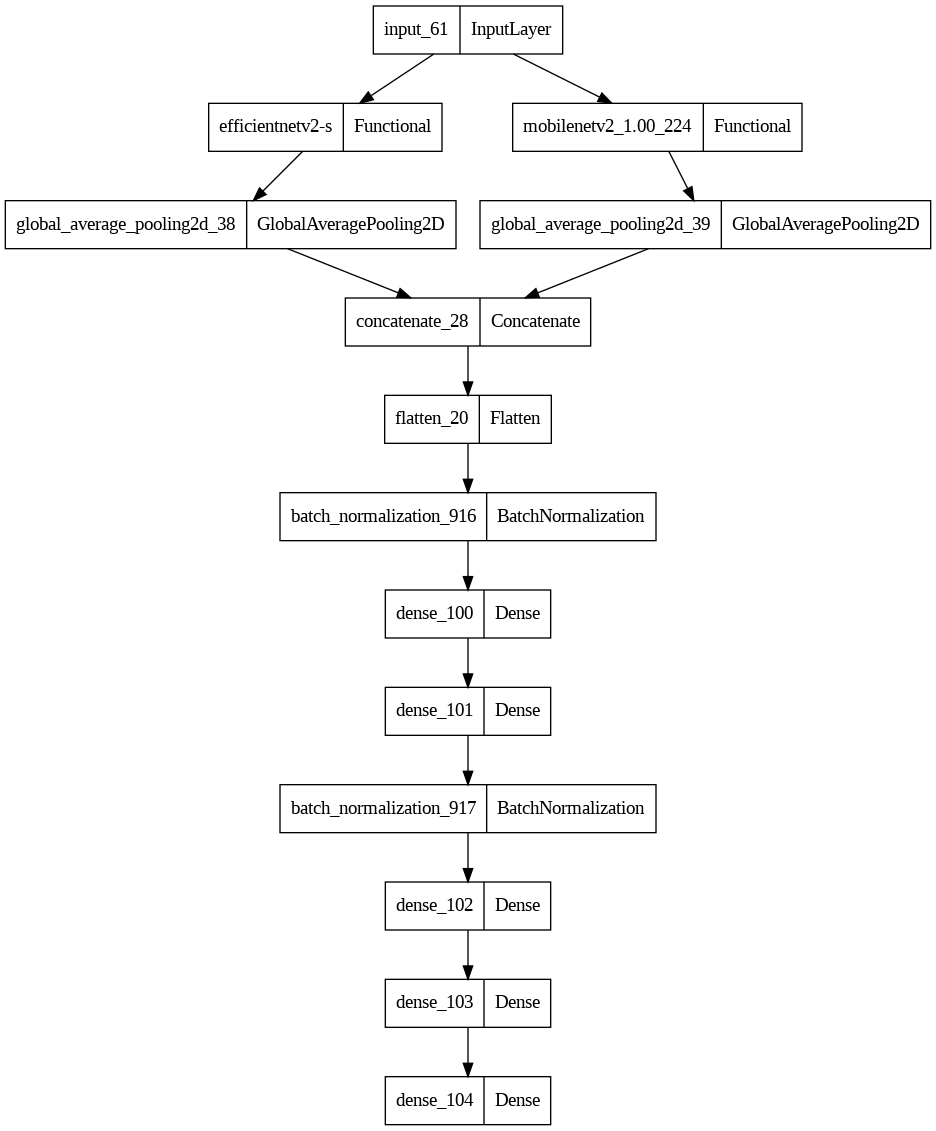

In [56]:
from tensorflow.keras.utils import plot_model
plot_model(model,'model.png')


In [85]:
test_loss, test_accuracy = model.evaluate(val_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

6/6 [==============================] - 3s 432ms/step - loss: 0.0455 - accuracy: 0.9814
Test Loss: 0.0455
Test Accuracy: 0.9814


<Figure size 640x480 with 0 Axes>

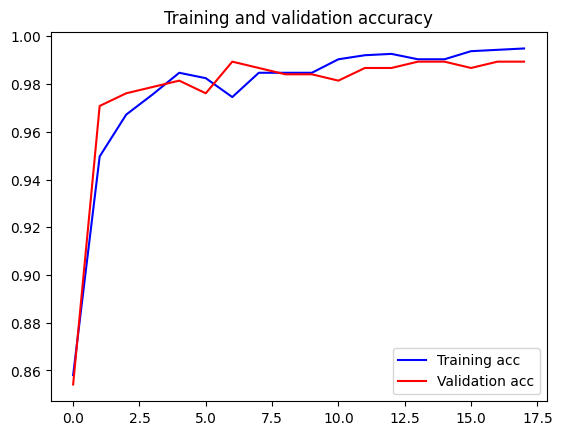

<Figure size 640x480 with 0 Axes>

In [70]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

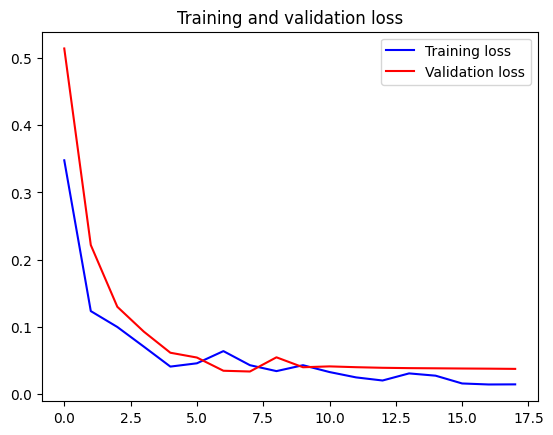

In [71]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

6/6 [==============================] - 19s 2s/step


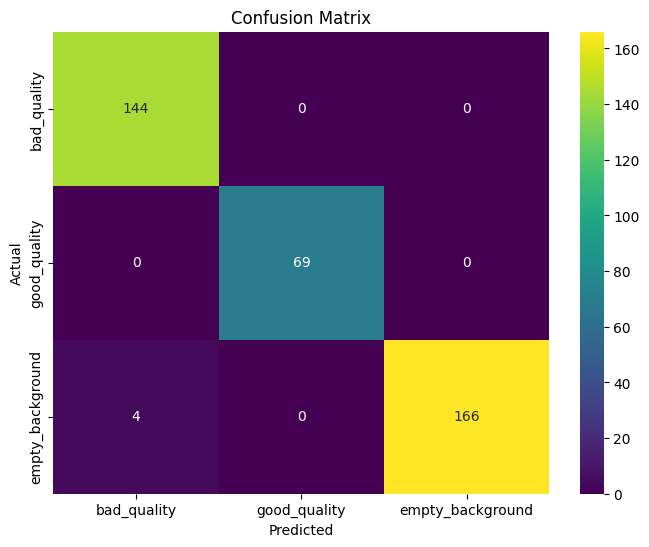

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

6/6 [==============================] - 3s 463ms/step


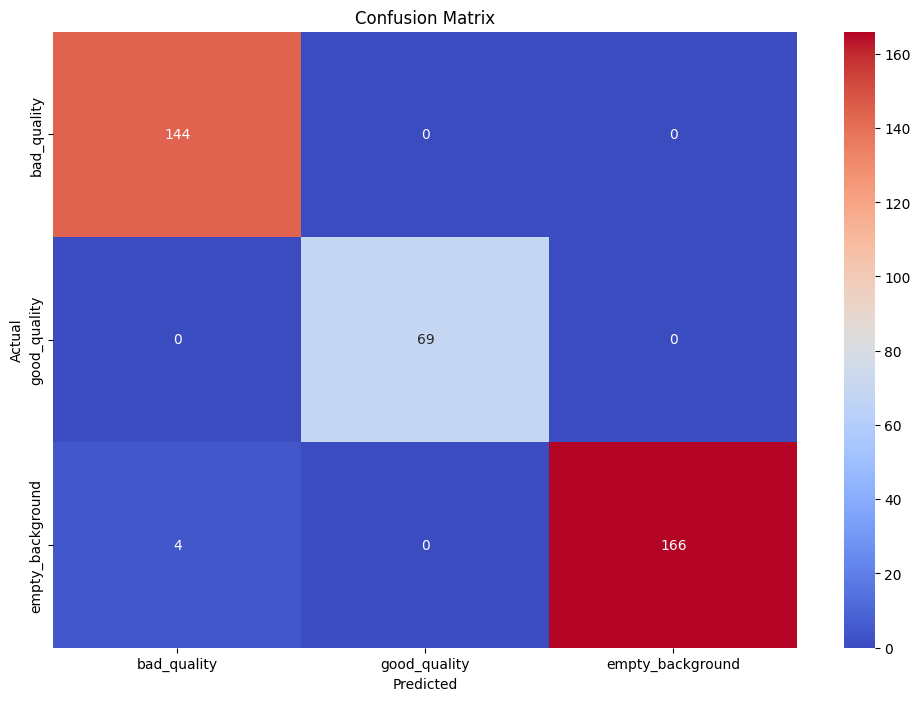

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

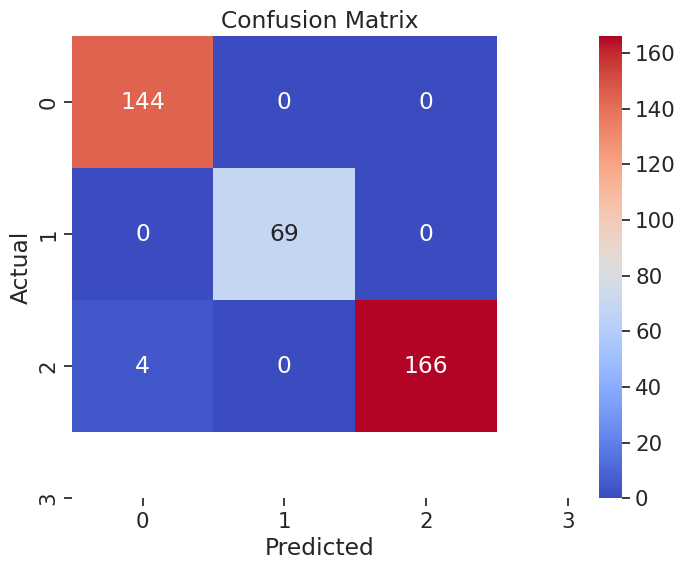

In [74]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


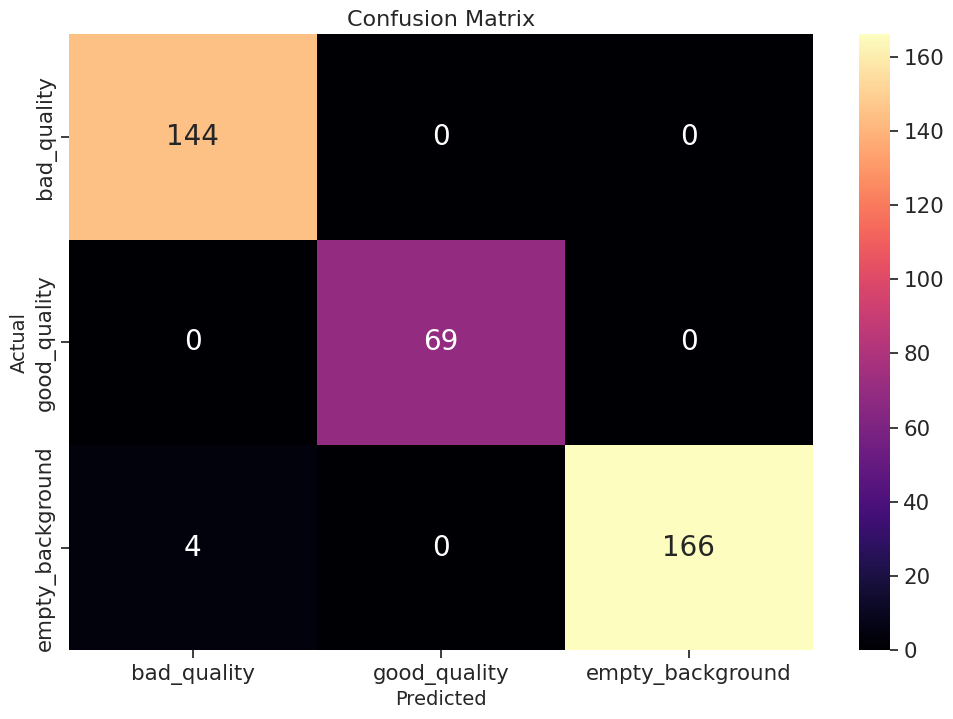

In [75]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


In [76]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

In [77]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.97      1.00      0.99       144
           1       1.00      1.00      1.00        69
           2       1.00      0.98      0.99       170

    accuracy                           0.99       383
   macro avg       0.99      0.99      0.99       383
weighted avg       0.99      0.99      0.99       383



<Figure size 640x480 with 0 Axes>

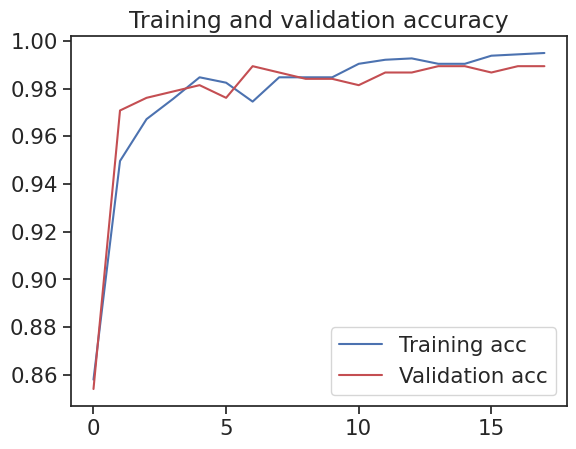

<Figure size 640x480 with 0 Axes>

In [78]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

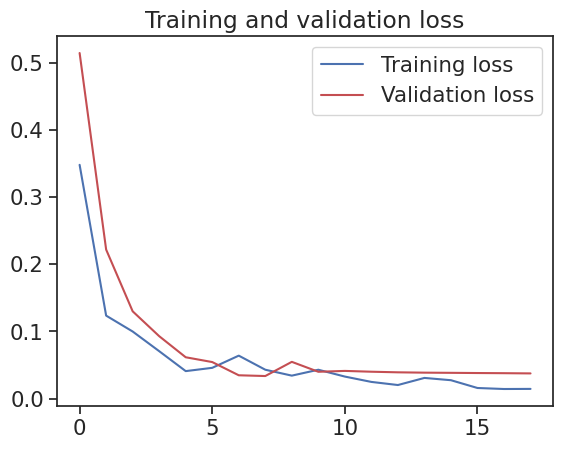

In [79]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

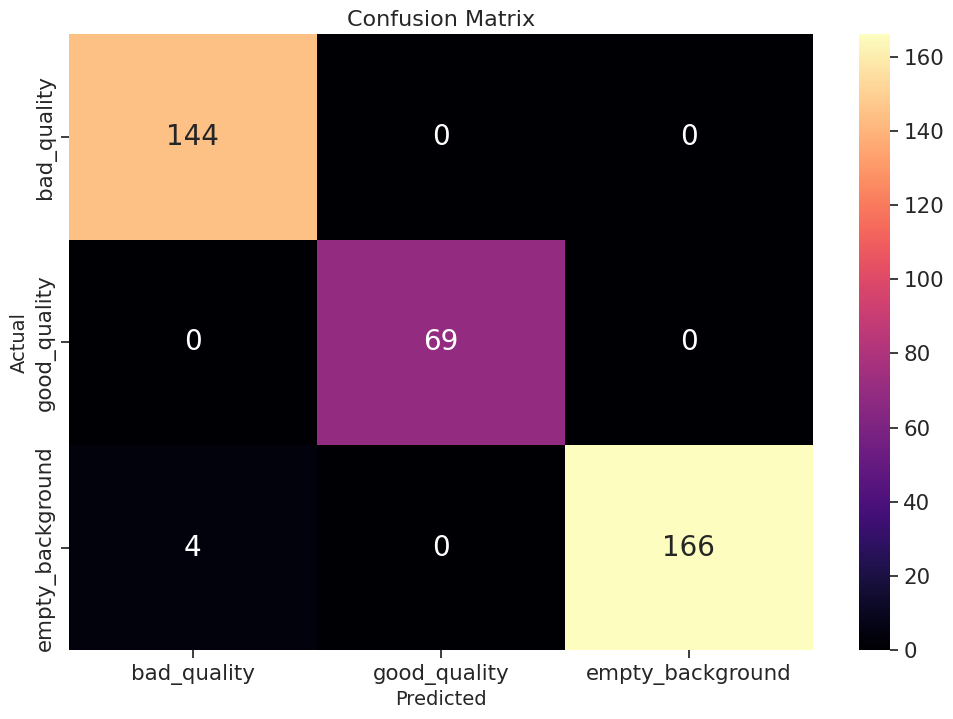

In [80]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


6/6 [==============================] - 3s 432ms/step


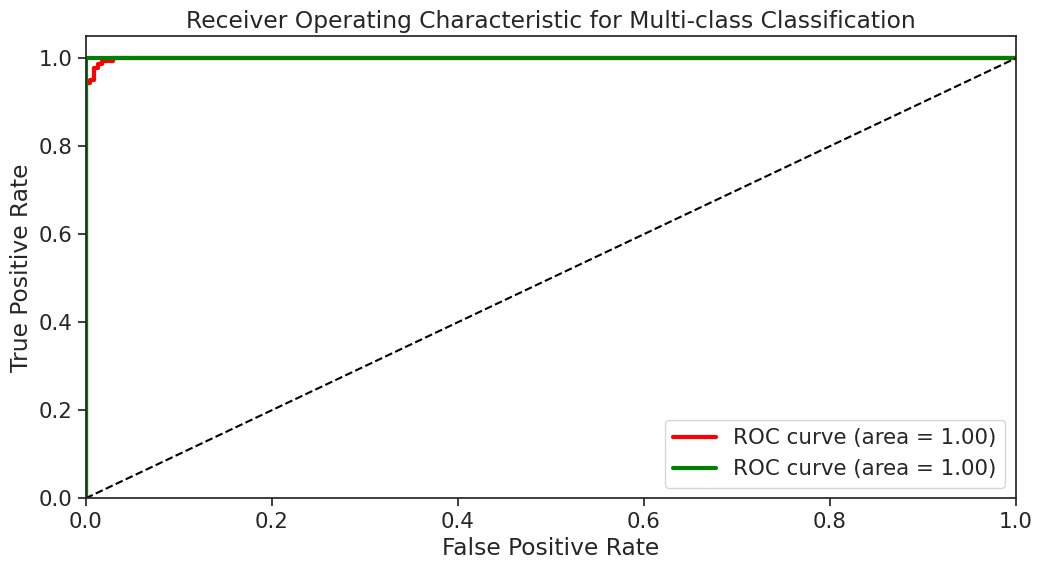

AUC scores:
Class 1: 0.9993107581660173
Class 2: 1.0


In [81]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 2  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')

In [82]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()

6/6 [==============================] - 3s 431ms/step
Class bad_quality:
Precision: 0.9730
Recall: 1.0000
F1-score: 0.9863

Class good_quality:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class empty_background:
Precision: 1.0000
Recall: 0.9765
F1-score: 0.9881



In [83]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))

6/6 [==============================] - 3s 449ms/step
                  precision    recall  f1-score   support

     bad_quality       0.97      1.00      0.99       144
    good_quality       1.00      1.00      1.00        69
empty_background       1.00      0.98      0.99       170

        accuracy                           0.99       383
       macro avg       0.99      0.99      0.99       383
    weighted avg       0.99      0.99      0.99       383



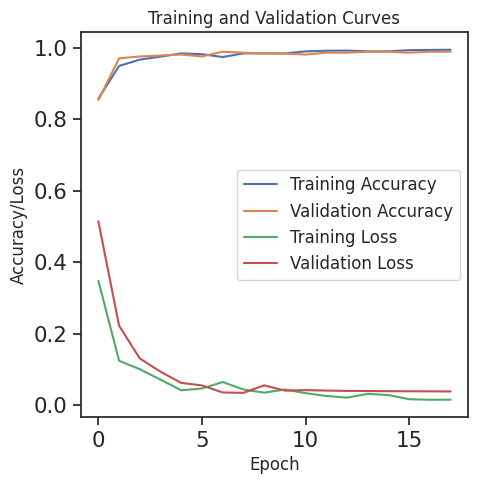

In [84]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progress.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progress.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progress.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progress.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()